# 08 — Ensemble Selection (Roadmap Step 3)

**Reporting only -- nothing here retrains or re-runs anything.** No companion
script exists for this notebook (unlike 05/06/07), because every input it
needs -- OOF predictions for every candidate model, per (repeat, fold) -- already
exists on disk from `05_cv_comparison`, `06_outlier_check`, and
`07_weighting_tuning`. This notebook only loads those already-completed
prediction files, simple-averages them within candidate combinations, and
re-scores the averages through the same bootstrap/vendor-eval pipeline used
throughout this project (`src.vendor.openadmet_eval.evaluate_predictions.
score_activity_predictions`, wrapped by `src.cv_bootstrap.per_fold_bootstrap_
seed`) -- matching 05/06/07's own aggregation convention: point estimate =
mean of the 1,000-sample bootstrap distribution.

## Scope: simple-average ensembling only

This step tests **simple-average ensembles only** -- every combination tested
gets equal weight `1/n` across its `n` members, nothing is fit to the OOF
predictions. This is deliberately narrower than "ensembling" in general:

- **No weight-fitting.** Fitting ensemble weights on the same OOF predictions
  used for evaluation would be a leakage pattern this project has avoided
  everywhere else -- the same reasoning as 07's inner-fold-only hyperparameter
  search (fitting *and* evaluating on the same held-out predictions lets the
  fit chase this particular resample's noise). A properly nested
  weight-fitting design (fit weights on inner folds, evaluate on the outer
  held-out fold) is a real possibility for a future step, but is **deferred,
  not adopted**, until it is scoped separately.
- **No retraining.** Every model's OOF predictions already exist on disk from
  05/06/07; this notebook only averages existing predictions and re-scores
  them. No `chemprop`/`sklearn`/`lightgbm` model is fit anywhere below.
- **Selection, not fitting.** For each isoform, every non-trivial subset of
  that isoform's candidate pool is tested (every 2-, 3-, ..., n-way
  combination), each scored as a plain equal-weight average, and compared
  against the current best single model via the same paired-fold significance
  test 06/07 established. The winning option (single model or one specific
  combo) is whichever has the lowest mean ST-RAE among those not eliminated
  by that isoform's own decision rule -- stated explicitly in each isoform's
  own cell below.

## Candidate pools

Each isoform's candidate pool is taken directly from 05's compact-letter-display
(CLD) leaderboard (`outputs/05_cv_comparison/leaderboard_{isoform}.csv`,
Section 3 of that notebook) and, for CYP2D6, from 07's own per-config outcome
(`outputs/07_weighting_tuning/step2_summary.csv`, Section 6 of that notebook).
Pools are **not** re-derived from raw scores here -- the cells below load
those two already-computed artifacts directly, and each isoform's own markdown
cell states its pool and where it came from before any scoring happens.

In [1]:
import itertools
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))  # so `from src... import ...` works regardless of cwd

import importlib.metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import shapiro, ttest_rel, wilcoxon

from src.cv_bootstrap import per_fold_bootstrap_seed
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS
from src.vendor.openadmet_eval.evaluate_predictions import score_activity_predictions

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "seaborn", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

OUT05 = REPO_ROOT / "outputs" / "05_cv_comparison"
OUT06 = REPO_ROOT / "outputs" / "06_outlier_check"
OUT07 = REPO_ROOT / "outputs" / "07_weighting_tuning"
OUT = REPO_ROOT / "outputs" / "08_ensemble_selection"
PRED_OUT, SCORE_OUT, FIG_OUT = OUT / "predictions", OUT / "scores", OUT / "figures"
for d in (PRED_OUT, SCORE_OUT, FIG_OUT):
    d.mkdir(parents=True, exist_ok=True)

CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
curated = pd.read_csv(CURATED_PATH)
print(f"curated: {curated.shape}")

PRED_DIRS = {"05": OUT05 / "predictions", "06": OUT06 / "predictions", "07": OUT07 / "predictions"}
SCORE_DIRS = {"05": OUT05 / "scores", "06": OUT06 / "scores", "07": OUT07 / "scores"}

METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]
METRICS = ["ST-RAE", "R2"]  # matches 06/07's own before/after reporting scope
N_REPEATS, N_FOLDS = 5, 5
ALPHA = 0.05

# Bootstrap seed is shared across every config for a given (repeat, fold) -- confirmed
# in 05's own manifest.csv (nunique(seed) per (repeat, fold) == 1) -- so any config's
# manifest row gives the seed to reuse when re-scoring an ensemble average for that
# fold. Fold-varying (never a single global seed), per this project's seeding rule.
manifest = pd.read_csv(OUT05 / "manifest.csv")
seed_lookup = manifest.drop_duplicates(["repeat", "fold"]).set_index(["repeat", "fold"])["seed"]
assert manifest.groupby(["repeat", "fold"])["seed"].nunique().eq(1).all(), "seed not shared across configs for some fold"
print(f"fold seeds loaded: {len(seed_lookup)} (repeat, fold) pairs")
print(f"  e.g. seed(repeat=0, fold=0)={seed_lookup.loc[(0, 0)]}, seed(repeat=4, fold=4)={seed_lookup.loc[(4, 4)]}")

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
seaborn: 0.13.2
matplotlib: 3.11.1
curated: (4905, 20)
fold seeds loaded: 25 (repeat, fold) pairs
  e.g. seed(repeat=0, fold=0)=2684470948, seed(repeat=4, fold=4)=3405943863


**What this shows:** the curated dataset and the three source notebooks'
prediction/score directories load cleanly, and the per-(repeat, fold)
bootstrap-seed lookup confirms every config scored in this project for a
given fold shares that fold's seed -- fold-varying, never a single global
seed. Reusing it here is what makes the paired fold-level significance tests
below valid: each fold's bootstrap resample is identical across every
model/combo compared on that fold, exactly as it was across every config
compared in 05/06/07.

## Shared helper functions

The same four-step pipeline (load a pool's OOF predictions, simple-average one
subset, re-score it, paired-compare it to the single best) repeats for every
isoform with more than one candidate. Factored here once, in a notebook-local
cell, rather than duplicated three times or split into a new `scripts/` file
-- per this step's own scope note on helper functions.

In [2]:
def load_model_oof(source: str, tag: str, isoform_col: str) -> pd.DataFrame:
    '''Load one model's 25 (repeat, fold) OOF prediction files for one isoform
    column, concatenated with repeat/fold columns attached.'''
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = PRED_DIRS[source] / f"{tag}__repeat{repeat}_fold{fold}.csv"
            df = pd.read_csv(path, usecols=["Molecule_Name", "inchikey", isoform_col])
            df["repeat"], df["fold"] = repeat, fold
            rows.append(df)
    return pd.concat(rows, ignore_index=True)


def build_pool_wide(pool_specs: dict, isoform_col: str) -> pd.DataFrame:
    '''One row per (repeat, fold, inchikey), one column per pool member's OOF
    prediction for `isoform_col`, inner-joined on (repeat, fold, inchikey). Row
    counts are logged and the join is asserted lossless, so a silent compound-set
    mismatch between pool members (e.g. a different exclusion criterion) cannot
    pass unnoticed into the averaging step below.'''
    wide, n_first = None, None
    for name, (source, tag) in pool_specs.items():
        long_df = load_model_oof(source, tag, isoform_col).rename(columns={isoform_col: name})
        print(f"  loaded {name} ({source}/{tag}): {len(long_df)} rows ({N_REPEATS * N_FOLDS} folds)")
        if wide is None:
            wide = long_df[["repeat", "fold", "inchikey", "Molecule_Name", name]]
            n_first = len(wide)
        else:
            wide = wide.merge(long_df[["repeat", "fold", "inchikey", name]], on=["repeat", "fold", "inchikey"], how="inner")
    print(f"  pool wide table after inner-join on (repeat, fold, inchikey): {len(wide)} rows (first member alone: {n_first} rows)")
    assert len(wide) == n_first, "inner join dropped rows -- pool members do not share an identical compound set per fold"
    return wide


def score_predictions(pred_df: pd.DataFrame, isoform_col: str, seed: int) -> pd.DataFrame:
    '''Score one (repeat, fold)'s predictions for one isoform column through the
    vendored bootstrap pipeline, using that fold's manifest seed -- same pattern as
    `scripts/cyp2d6_outlier_check.py::score_and_save_cyp2d6`.'''
    ground_truth = curated[curated["inchikey"].isin(pred_df["inchikey"])].copy()
    with per_fold_bootstrap_seed(int(seed)):
        scored = score_activity_predictions(pred_df[["Molecule_Name", "inchikey", isoform_col]], ground_truth, [isoform_col])
    return scored


def point_estimate(scored: pd.DataFrame, isoform_col: str) -> dict:
    pe = scored.groupby("Endpoint")[METRIC_NAMES].mean()
    return {m: float(pe.loc[isoform_col, m]) for m in METRICS}


def load_existing_fold_scores(source: str, tag: str, isoform_col: str) -> pd.DataFrame:
    '''Load an already-computed model's 25 per-fold point estimates directly from
    its existing score CSVs on disk (05/06/07) -- no new bootstrap is run here.'''
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            path = SCORE_DIRS[source] / f"{tag}__repeat{repeat}_fold{fold}.csv"
            pe = point_estimate(pd.read_csv(path), isoform_col)
            rows.append({"repeat": repeat, "fold": fold, **pe})
    return pd.DataFrame(rows).sort_values(["repeat", "fold"]).reset_index(drop=True)


def score_combo(isoform: str, isoform_col: str, wide: pd.DataFrame, members: tuple, tag_prefix: str) -> pd.DataFrame:
    '''Simple-average `members`' predictions per (repeat, fold), score each fold,
    save predictions+scores to disk, and return the 25 per-fold point estimates.'''
    combo_key = "+".join(members)
    rows = []
    for repeat in range(N_REPEATS):
        for fold in range(N_FOLDS):
            fold_df = wide[(wide["repeat"] == repeat) & (wide["fold"] == fold)]
            pred_df = fold_df[["Molecule_Name", "inchikey"]].copy()
            pred_df[isoform_col] = fold_df[list(members)].mean(axis=1)

            seed = int(seed_lookup.loc[(repeat, fold)])
            scored = score_predictions(pred_df, isoform_col, seed)
            scored["combo"], scored["repeat"], scored["fold"], scored["bootstrap_seed"] = combo_key, repeat, fold, seed

            tag = f"{tag_prefix}__{combo_key}__repeat{repeat}_fold{fold}"
            pred_df.to_csv(PRED_OUT / f"{tag}.csv", index=False)
            scored.to_csv(SCORE_OUT / f"{tag}.csv", index=False)

            rows.append({"isoform": isoform, "combo": combo_key, "repeat": repeat, "fold": fold, **point_estimate(scored, isoform_col)})
    return pd.DataFrame(rows)


def paired_test(before: np.ndarray, after: np.ndarray) -> dict:
    '''Shapiro-Wilk on the 25 (after - before) deltas; paired t-test if normal,
    Wilcoxon signed-rank otherwise. No BH/Bonferroni correction -- identical method
    to 06/07's own before/after comparisons.'''
    delta = after - before
    shapiro_p = float(shapiro(delta).pvalue)
    normal = shapiro_p >= ALPHA
    if normal:
        test_name, (_, p_value) = "paired t-test", ttest_rel(after, before)
    else:
        test_name, (_, p_value) = "Wilcoxon signed-rank", wilcoxon(delta)
    return {
        "before_mean": float(before.mean()), "after_mean": float(after.mean()), "delta_mean": float(delta.mean()),
        "shapiro_p": shapiro_p, "branch": "parametric" if normal else "nonparametric",
        "test": test_name, "p_value": float(p_value), "significant": bool(p_value < ALPHA),
    }


def plot_correlation_heatmap(wide: pd.DataFrame, members: list, isoform: str, path: Path) -> pd.DataFrame:
    corr = wide[members].corr(method="pearson")
    fig, ax = plt.subplots(figsize=(1.6 * len(members) + 2, 1.4 * len(members) + 2))
    sns.heatmap(corr, annot=True, fmt=".3f", cmap="viridis", vmin=corr.to_numpy()[~np.eye(len(members), dtype=bool)].min() - 0.02,
                vmax=1.0, square=True, linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"label": "Pearson r (pooled OOF predictions)"})
    ax.set_title(f"{isoform} pool: pairwise OOF-prediction correlation", fontsize=12, fontweight="bold")
    plt.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {path}")
    return corr


def run_isoform_ensemble_selection(isoform: str, pool_specs: dict, single_best_label: str, single_best_source: str, single_best_tag: str):
    '''Full pipeline for one isoform: pairwise correlation, every non-trivial
    subset scored, paired-compared to the single best, decision rule applied.
    Returns (combo_summary_df, comparison_df, outcome_dict).'''
    isoform_col = f"{isoform}_pIC50_direct_inhibition"
    members = list(pool_specs)
    print(f"=== {isoform}: pool = {members} ===")
    wide = build_pool_wide(pool_specs, isoform_col)

    corr = wide[members].corr(method="pearson")
    print("pairwise Pearson r (pooled OOF predictions, all 25 folds):")
    print(corr.round(3).to_string())
    if len(members) > 2:
        plot_correlation_heatmap(wide, members, isoform, FIG_OUT / f"correlation_heatmap_{isoform}.png")

    single_best = load_existing_fold_scores(single_best_source, single_best_tag, isoform_col)
    single_best_st_rae = single_best["ST-RAE"].to_numpy()
    print(f"single best ({single_best_label}): mean ST-RAE across 25 folds = {single_best_st_rae.mean():.4f}")

    combo_rows, comparison_rows = [], []
    for r in range(2, len(members) + 1):
        for combo in itertools.combinations(members, r):
            combo_df = score_combo(isoform, isoform_col, wide, combo, tag_prefix=isoform)
            combo_df = combo_df.sort_values(["repeat", "fold"]).reset_index(drop=True)
            assert (combo_df[["repeat", "fold"]].to_numpy() == single_best[["repeat", "fold"]].to_numpy()).all(), \
                "fold order mismatch between combo and single-best -- paired test would be invalid"
            combo_rows.append(combo_df)

            test = paired_test(single_best_st_rae, combo_df["ST-RAE"].to_numpy())
            comparison_rows.append({"isoform": isoform, "combo": "+".join(combo), "n_members": r, "vs": single_best_label, **test})

    combo_summary_df = pd.concat(combo_rows, ignore_index=True)
    comparison_df = pd.DataFrame(comparison_rows).sort_values("after_mean").reset_index(drop=True)
    print(f"\nscored {len(comparison_df)} non-trivial combos for {isoform}")
    display_cols = ["combo", "n_members", "before_mean", "after_mean", "delta_mean", "test", "p_value", "significant"]
    print(comparison_df[display_cols].rename(columns={"before_mean": "single_best_ST-RAE", "after_mean": "combo_ST-RAE"}).to_string(index=False))

    eligible = comparison_df[comparison_df["significant"] & (comparison_df["delta_mean"] < 0)]
    if len(eligible) > 0:
        winner_row = eligible.loc[eligible["after_mean"].idxmin()]
        outcome = {
            "isoform": isoform, "decision": "ensemble adopted", "winning_combo": winner_row["combo"],
            "winning_mean_ST-RAE": winner_row["after_mean"], "single_best_label": single_best_label,
            "single_best_mean_ST-RAE": float(single_best_st_rae.mean()), "p_value": winner_row["p_value"], "test": winner_row["test"],
        }
        print(f"\nDECISION: '{winner_row['combo']}' wins for {isoform} -- ST-RAE {single_best_st_rae.mean():.4f} -> {winner_row['after_mean']:.4f}, "
              f"{winner_row['test']} p={winner_row['p_value']:.3g}")
    else:
        outcome = {
            "isoform": isoform, "decision": "single model stands", "winning_combo": None,
            "winning_mean_ST-RAE": float(single_best_st_rae.mean()), "single_best_label": single_best_label,
            "single_best_mean_ST-RAE": float(single_best_st_rae.mean()), "p_value": None, "test": None,
        }
        print(f"\nDECISION: no combo clears the bar for {isoform} -- single best ({single_best_label}) stands at ST-RAE {single_best_st_rae.mean():.4f}")

    return combo_summary_df, comparison_df, outcome, single_best


all_combo_rows, all_comparison_rows, step3_outcomes = [], [], []

**What this shows:** the shared pipeline -- pairwise correlation first (a pure
diagnostic, computed and printed before any combo is scored), then every
non-trivial subset averaged and re-scored, then a paired Shapiro-Wilk /
t-test-or-Wilcoxon comparison of each combo's ST-RAE against the current
single best, then the decision rule (lowest-mean-ST-RAE among combos that
significantly beat the single best; single best stands if none do). Nothing
has been run yet for any isoform -- each one runs below in its own cell.

## CYP1A2

**Candidate pool** (05 CLD leaderboard, `leaderboard_CYP1A2.csv`, Section 3):
all four configs sharing CLD letter **"a"** -- `chemprop_chemeleoninit`,
`ecfp4_narrow__rf`, `chemeleon__rf`, `ecfp4_narrow__lightgbm` -- statistically
indistinguishable on ST-RAE at alpha=0.05 in 05's own comparison. 4 candidates
-> **11 non-trivial subsets** (6 pairs + 4 triples + 1 quadruple). Current
single best: `chemprop_chemeleoninit`, the lowest-ST-RAE member of tier "a"
(0.8685 vs. 0.8685/0.8718/0.8751 for the other three -- a near-tie by value,
consistent with none of the four being significantly different).

CLD                 config   ST-RAE
  a chemprop_chemeleoninit 0.868459
  a       ecfp4_narrow__rf 0.868478
  a          chemeleon__rf 0.871779
  a ecfp4_narrow__lightgbm 0.875099
=== CYP1A2: pool = ['chemprop_chemeleoninit', 'ecfp4_narrow__rf', 'chemeleon__rf', 'ecfp4_narrow__lightgbm'] ===
  loaded chemprop_chemeleoninit (05/chemprop_chemeleoninit): 24525 rows (25 folds)
  loaded ecfp4_narrow__rf (05/ecfp4_narrow__rf): 24525 rows (25 folds)
  loaded chemeleon__rf (05/chemeleon__rf): 24525 rows (25 folds)
  loaded ecfp4_narrow__lightgbm (05/ecfp4_narrow__lightgbm): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
pairwise Pearson r (pooled OOF predictions, all 25 folds):
                        chemprop_chemeleoninit  ecfp4_narrow__rf  chemeleon__rf  ecfp4_narrow__lightgbm
chemprop_chemeleoninit                   1.000             0.675          0.712                   0.669
ecfp4_narrow__rf              

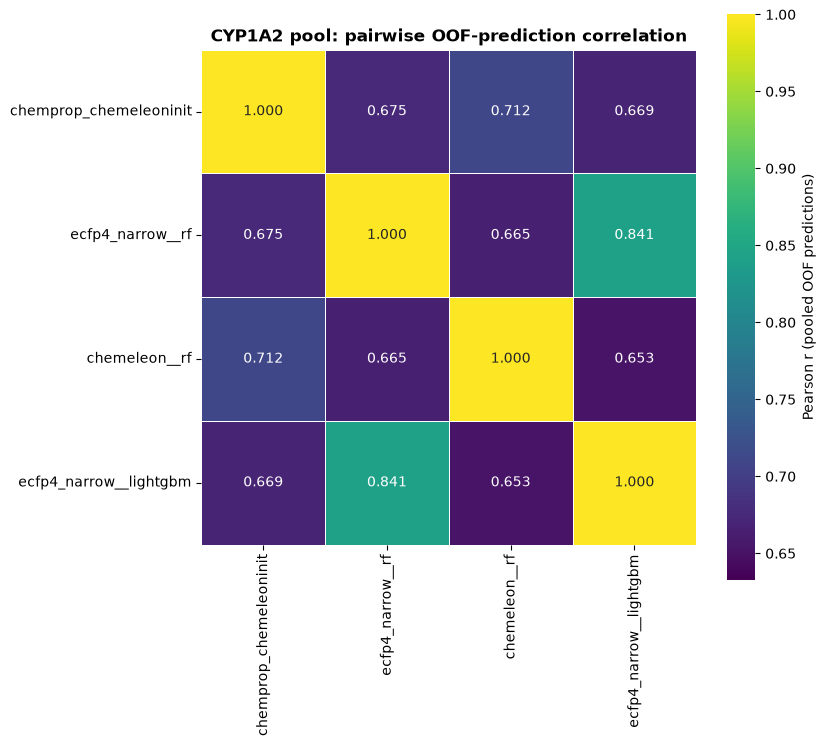

2026-09-03 11:31:23.958 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-03 11:31:23.959 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:31:23.959 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-03 11:31:23.959 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/08_ensemble_selection/figures/correlation_heatmap_CYP1A2.png
single best (chemprop_chemeleoninit): mean ST-RAE across 25 folds = 0.8685


...

2026-09-03 11:34:08.150 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:34:08.150 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-03 11:34:08.151 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 723 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


2026-09-03 11:34:08.744 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions



scored 11 non-trivial combos for CYP1A2
                                                                       combo  n_members  single_best_ST-RAE  combo_ST-RAE  delta_mean          test      p_value  significant
chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf+ecfp4_narrow__lightgbm          4            0.868459      0.802210   -0.066249 paired t-test 6.298245e-09         True
                 chemprop_chemeleoninit+chemeleon__rf+ecfp4_narrow__lightgbm          3            0.868459      0.802459   -0.066000 paired t-test 3.012048e-09         True
                       chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf          3            0.868459      0.803511   -0.064948 paired t-test 3.418241e-09         True
              chemprop_chemeleoninit+ecfp4_narrow__rf+ecfp4_narrow__lightgbm          3            0.868459      0.806771   -0.061688 paired t-test 5.233833e-09         True
                                     chemprop_chemeleoninit+ecfp4_narrow__rf          2  

In [3]:
CYP1A2_POOL = {
    "chemprop_chemeleoninit": ("05", "chemprop_chemeleoninit"),
    "ecfp4_narrow__rf": ("05", "ecfp4_narrow__rf"),
    "chemeleon__rf": ("05", "chemeleon__rf"),
    "ecfp4_narrow__lightgbm": ("05", "ecfp4_narrow__lightgbm"),
}

leaderboard_1a2 = pd.read_csv(OUT05 / "leaderboard_CYP1A2.csv")
print(leaderboard_1a2[leaderboard_1a2["config"].isin(CYP1A2_POOL)][["CLD", "config", "ST-RAE"]].to_string(index=False))
assert set(leaderboard_1a2.loc[leaderboard_1a2["CLD"] == "a", "config"]) == set(CYP1A2_POOL), "CYP1A2 pool does not match 05's CLD tier 'a'"

combo_df_1a2, comparison_df_1a2, outcome_1a2, single_best_1a2 = run_isoform_ensemble_selection(
    "CYP1A2", CYP1A2_POOL, single_best_label="chemprop_chemeleoninit", single_best_source="05", single_best_tag="chemprop_chemeleoninit",
)
all_combo_rows.append(combo_df_1a2)
all_comparison_rows.append(comparison_df_1a2)
step3_outcomes.append(outcome_1a2)

**What this shows:** all four CYP1A2 pool members pull in a genuinely
different direction from each other (pairwise r = 0.65-0.84, none near 1.0),
so the correlation diagnostic didn't rule anything out up front. Once every
combo is scored, 10 of the 11 beat `chemprop_chemeleoninit` significantly --
the one exception, `ecfp4_narrow__rf + ecfp4_narrow__lightgbm` (p=0.059, not
significant), is exactly the single most-correlated pair (r=0.841, sharing
the same `ecfp4_narrow` feature set) -- the diagnostic's own warning that
averaging two near-identical predictors buys little borne out directly. The
full 4-way average wins outright (ST-RAE 0.8685 -> 0.8022, paired t-test
p=6.3e-09), though the top 7 combos all sit within ~0.008 ST-RAE of each
other and every one of them includes `chemprop_chemeleoninit` -- the four
combos that drop it (bottom of the table) are all measurably worse,
identifying it as the load-bearing member of every strong CYP1A2 ensemble
rather than an interchangeable participant.

## CYP2C9 -- no ensemble tested

**Candidate pool** (05 CLD leaderboard, `leaderboard_CYP2C9.csv`, Section 3):
`chemprop_chemeleoninit` is **uniquely best** with CLD letter "a" and no
CLD-tied partner (the next config, `chemprop_randominit`, is letter "b" --
significantly worse). With only one candidate, there is no non-trivial subset
to average, so **no ensemble is tested for this isoform**: 05's
`chemprop_chemeleoninit` result carries forward unchanged as CYP2C9's step-3
outcome.

In [4]:
leaderboard_2c9 = pd.read_csv(OUT05 / "leaderboard_CYP2C9.csv")
print(leaderboard_2c9[["CLD", "config", "ST-RAE"]].head(3).to_string(index=False))
tier_a_2c9 = leaderboard_2c9.loc[leaderboard_2c9["CLD"] == "a", "config"].tolist()
assert tier_a_2c9 == ["chemprop_chemeleoninit"], f"expected CYP2C9 tier 'a' to be exactly ['chemprop_chemeleoninit'], got {tier_a_2c9}"

single_best_2c9 = load_existing_fold_scores("05", "chemprop_chemeleoninit", "CYP2C9_pIC50_direct_inhibition")
print(f"CYP2C9 single best (chemprop_chemeleoninit): mean ST-RAE across 25 folds = {single_best_2c9['ST-RAE'].mean():.4f}")

step3_outcomes.append({
    "isoform": "CYP2C9", "decision": "single model stands (no ensemble tested)", "winning_combo": None,
    "winning_mean_ST-RAE": float(single_best_2c9["ST-RAE"].mean()), "single_best_label": "chemprop_chemeleoninit",
    "single_best_mean_ST-RAE": float(single_best_2c9["ST-RAE"].mean()), "p_value": None, "test": None,
})

CLD                 config   ST-RAE
  a chemprop_chemeleoninit 0.678691
  b    chemprop_randominit 0.744176
  b       ecfp4_narrow__rf 0.745922
CYP2C9 single best (chemprop_chemeleoninit): mean ST-RAE across 25 folds = 0.6787


**What this shows:** with only one CLD-tier-"a" candidate, there is nothing
to average -- `chemprop_chemeleoninit`'s already-known CYP2C9 result
(ST-RAE 0.6787, loaded here straight from 05's own score files, not
recomputed) carries forward unchanged as this isoform's step-3 outcome.

## CYP2D6

**Candidate pool** (07's own outcome, `step2_summary.csv`, Section 6 -- not
05's original CLD tier, since 06/07 changed two of the three members' best
known version since 05 was written):

- `chemeleon__rf` -- **07's tuned version** (`tuning__chemeleon__rf` in
  `outputs/07_weighting_tuning/predictions/`). 07 found tuning significant and
  better than 06's residual-excluded baseline (ST-RAE 0.9021 -> 0.8968).
- `chemeleon__lightgbm` -- **06's residual-excluded baseline**
  (`residual__chemeleon__lightgbm` in `outputs/06_outlier_check/predictions/`).
  07 tested tuning for this config too but found it did not clear
  significance (p=0.39), so the 06 residual-excluded version remains its best
  known state.
- `chemprop_chemeleoninit` -- **06's residual-excluded baseline**
  (`residual__chemprop_chemeleoninit`). Deferred from 07 entirely (07's own
  scope note), so its 06 result is still its best known state going into this
  step.

**Exclusion note (judgement call, not a hard rule):** `ecfp4_narrow__lightgbm`
was part of 05's original CYP2D6 CLD tier "a" but is **excluded from this
pool**. 06 found its residual-exclusion ST-RAE improvement fell just short of
significance (p=0.052, the near-miss) -- already deprioritized before this
step. Flagged explicitly here rather than silently omitted; its correlation
with the three pool members above is checked as a diagnostic below before
proceeding, in case that changes the picture.

3 candidates -> **4 non-trivial subsets** (3 pairs + the 3-way combo).
Current single best: `chemeleon__rf` (07 tuned), ST-RAE 0.8968 -- the lowest
of the three current-best-per-config values (0.8968 vs. 0.9302 `chemeleon__
lightgbm` vs. 0.9343 `chemprop_chemeleoninit`).

             config  baseline_ST-RAE  weighted_ST-RAE  weighted_significant  tuned_ST-RAE  tuned_significant           recommended_for_step3
      chemeleon__rf         0.902073          0.97886                  True      0.896770               True                           tuned
chemeleon__lightgbm         0.930195          0.99208                  True      0.926399              False baseline (06 residual-excluded)
  loaded chemeleon__rf (07/tuning__chemeleon__rf): 24525 rows (25 folds)
  loaded chemeleon__lightgbm (06/residual__chemeleon__lightgbm): 24525 rows (25 folds)
  loaded chemprop_chemeleoninit (06/residual__chemprop_chemeleoninit): 24525 rows (25 folds)


  loaded ecfp4_narrow__lightgbm (excluded, diagnostic only) (06/residual__ecfp4_narrow__lightgbm): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)

CYP2D6 pool + excluded ecfp4_narrow__lightgbm -- pairwise Pearson r (pooled OOF predictions):
                                                    chemeleon__rf  chemeleon__lightgbm  chemprop_chemeleoninit  ecfp4_narrow__lightgbm (excluded, diagnostic only)
chemeleon__rf                                               1.000                0.769                   0.631                                               0.489
chemeleon__lightgbm                                         0.769                1.000                   0.584                                               0.456
chemprop_chemeleoninit                                      0.631                0.584                   1.000                                               0.552
ecfp4_narrow__lightgbm (

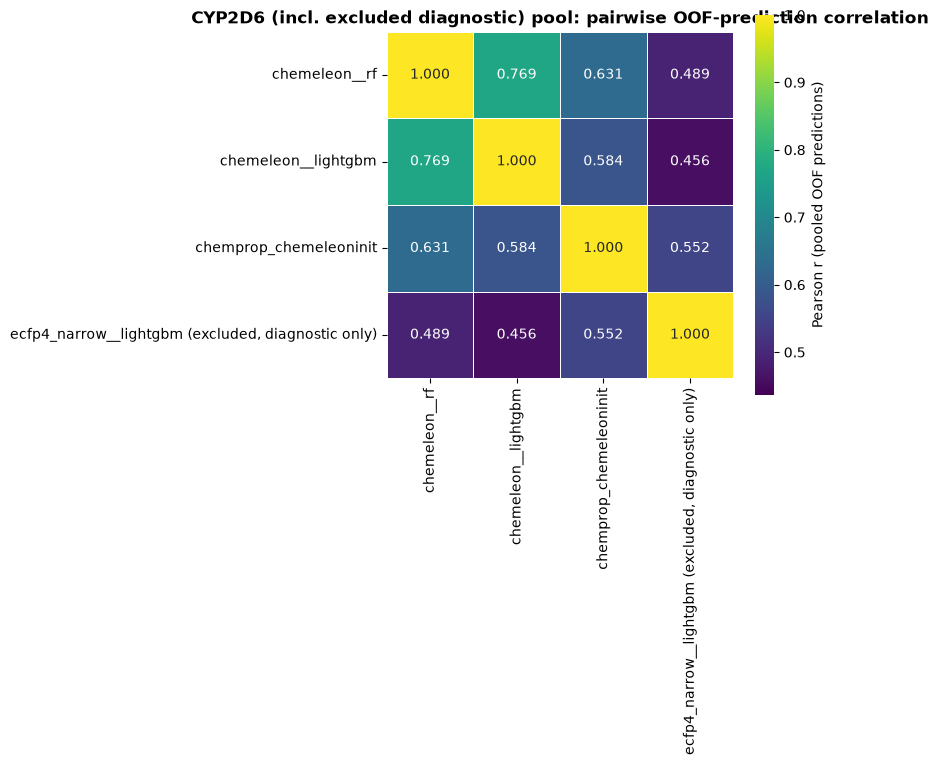

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/08_ensemble_selection/figures/correlation_heatmap_CYP2D6_diagnostic.png


,chemeleon__rf,chemeleon__lightgbm,chemprop_chemeleoninit,"ecfp4_narrow__lightgbm (excluded, diagnostic only)"
chemeleon__rf,1.000000,0.768926,0.630901,0.489173
chemeleon__lightgbm,0.768926,1.000000,0.583986,0.456272
chemprop_chemeleoninit,0.630901,0.583986,1.000000,0.552478
"ecfp4_narrow__lightgbm (excluded, diagnostic only)",0.489173,0.456272,0.552478,1.000000


In [5]:
CYP2D6_POOL = {
    "chemeleon__rf": ("07", "tuning__chemeleon__rf"),
    "chemeleon__lightgbm": ("06", "residual__chemeleon__lightgbm"),
    "chemprop_chemeleoninit": ("06", "residual__chemprop_chemeleoninit"),
}

step2_summary = pd.read_csv(OUT07 / "step2_summary.csv")
print(step2_summary.to_string(index=False))
assert step2_summary.loc[step2_summary["config"] == "chemeleon__rf", "recommended_for_step3"].iloc[0] == "tuned"
assert step2_summary.loc[step2_summary["config"] == "chemeleon__lightgbm", "recommended_for_step3"].iloc[0] == "baseline (06 residual-excluded)"

# diagnostic only: does ecfp4_narrow__lightgbm's correlation with the pool change the
# exclusion call? Uses its own 06 residual-excluded predictions, for an apples-to-apples
# comparison against the pool (all three pool members are also post-06/07 versions).
CYP2D6_DIAGNOSTIC_POOL = {**CYP2D6_POOL, "ecfp4_narrow__lightgbm (excluded, diagnostic only)": ("06", "residual__ecfp4_narrow__lightgbm")}
diagnostic_wide = build_pool_wide(CYP2D6_DIAGNOSTIC_POOL, "CYP2D6_pIC50_direct_inhibition")
diagnostic_corr = diagnostic_wide[list(CYP2D6_DIAGNOSTIC_POOL)].corr(method="pearson")
print("\nCYP2D6 pool + excluded ecfp4_narrow__lightgbm -- pairwise Pearson r (pooled OOF predictions):")
print(diagnostic_corr.round(3).to_string())
plot_correlation_heatmap(diagnostic_wide, list(CYP2D6_DIAGNOSTIC_POOL), "CYP2D6 (incl. excluded diagnostic)", FIG_OUT / "correlation_heatmap_CYP2D6_diagnostic.png")

**What this shows:** the excluded `ecfp4_narrow__lightgbm` correlates only
moderately with all three CYP2D6 pool members (r=0.49 vs. `chemeleon__rf`,
0.46 vs. `chemeleon__lightgbm`, 0.55 vs. `chemprop_chemeleoninit`) --
noticeably lower than the pool members correlate with each other (0.77
between the two `chemeleon` models, 0.58-0.63 involving `chemprop_
chemeleoninit`). A model that far out on its own from the rest of the pool is
exactly the profile that can sometimes add ensemble value despite being the
weakest single performer, so this was surfaced to the user before finalizing
the pool rather than deciding either way silently. **Decision (confirmed):**
keep the exclusion and proceed with the 3-candidate pool as originally
scoped -- 06's p=0.052 near-miss was already a deliberate, previously
confirmed judgement call, and this step's job is selecting among the
specified pool, not re-litigating that call. `ecfp4_narrow__lightgbm` is not
tested in any combo below.

**Follow-up (below):** the user asked to test this further as an explicit additional check -- an extended-pool re-test that includes `ecfp4_narrow__lightgbm` alongside the 3-candidate pool's own winning combo, comparing against the *current champion* (not the older single model) to decide whether to keep it in going forward.

=== CYP2D6: pool = ['chemeleon__rf', 'chemeleon__lightgbm', 'chemprop_chemeleoninit'] ===


  loaded chemeleon__rf (07/tuning__chemeleon__rf): 24525 rows (25 folds)
  loaded chemeleon__lightgbm (06/residual__chemeleon__lightgbm): 24525 rows (25 folds)
  loaded chemprop_chemeleoninit (06/residual__chemprop_chemeleoninit): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
pairwise Pearson r (pooled OOF predictions, all 25 folds):
                        chemeleon__rf  chemeleon__lightgbm  chemprop_chemeleoninit
chemeleon__rf                   1.000                0.769                   0.631
chemeleon__lightgbm             0.769                1.000                   0.584
chemprop_chemeleoninit          0.631                0.584                   1.000


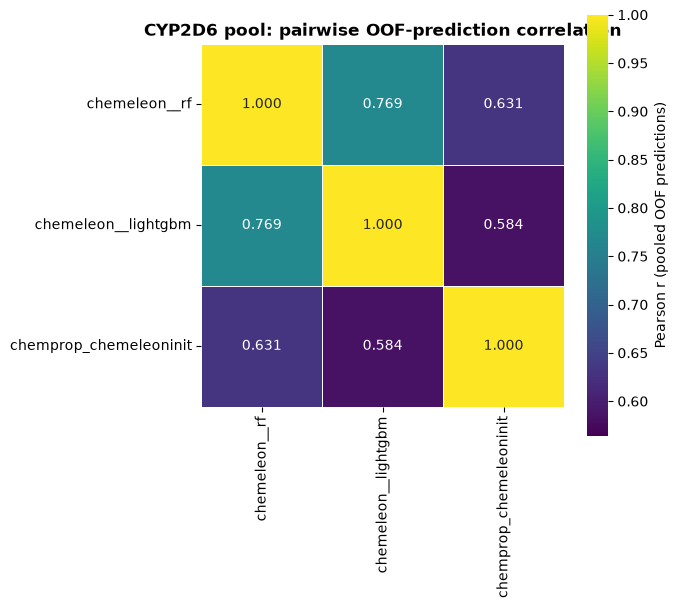

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/08_ensemble_selection/figures/correlation_heatmap_CYP2D6.png


2026-09-03 11:34:09.427 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-03 11:34:09.429 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:34:09.429 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2D6_pIC50_direct_inhibition


2026-09-03 11:34:09.429 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 686 compound(s) with no ground truth for endpoint CYP2D6_pIC50_direct_inhibition


...

2026-09-03 11:35:09.416 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:35:09.416 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2D6_pIC50_direct_inhibition


2026-09-03 11:35:09.416 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 686 compound(s) with no ground truth for endpoint CYP2D6_pIC50_direct_inhibition


2026-09-03 11:35:10.007 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions



scored 4 non-trivial combos for CYP2D6
                                                   combo  n_members  single_best_ST-RAE  combo_ST-RAE  delta_mean          test  p_value  significant
                    chemeleon__rf+chemprop_chemeleoninit          2             0.89677      0.877152   -0.019618 paired t-test 0.000003         True
chemeleon__rf+chemeleon__lightgbm+chemprop_chemeleoninit          3             0.89677      0.878596   -0.018174 paired t-test 0.000002         True
              chemeleon__lightgbm+chemprop_chemeleoninit          2             0.89677      0.889681   -0.007089 paired t-test 0.124364        False
                       chemeleon__rf+chemeleon__lightgbm          2             0.89677      0.901911    0.005141 paired t-test 0.038302         True

DECISION: 'chemeleon__rf+chemprop_chemeleoninit' wins for CYP2D6 -- ST-RAE 0.8968 -> 0.8772, paired t-test p=2.79e-06


In [6]:
combo_df_2d6, comparison_df_2d6, outcome_2d6, single_best_2d6 = run_isoform_ensemble_selection(
    "CYP2D6", CYP2D6_POOL, single_best_label="chemeleon__rf (07 tuned)", single_best_source="07", single_best_tag="tuning__chemeleon__rf",
)
assert np.isclose(single_best_2d6["ST-RAE"].mean(), step2_summary.loc[step2_summary["config"] == "chemeleon__rf", "tuned_ST-RAE"].iloc[0]), \
    "CYP2D6 single-best ST-RAE does not match 07's own saved tuned_ST-RAE"
all_combo_rows.append(combo_df_2d6)
all_comparison_rows.append(comparison_df_2d6)
step3_outcomes.append(outcome_2d6)

**What this shows:** two of the four combos beat `chemeleon__rf` (07's tuned
version) significantly, one doesn't, and one is **significantly worse** --
the only regression found anywhere in this notebook. `chemeleon__rf +
chemeleon__lightgbm` (the two tabular models, without `chemprop_
chemeleoninit`) makes ST-RAE significantly *worse* (0.8968 -> 0.9019,
p=0.038) -- averaging two correlated tabular models (r=0.769, the highest
pairwise correlation in this pool) with no complementary signal from the
multitask model actively hurts here, a real result "every non-trivial subset
gets tested" was designed to catch. `chemeleon__lightgbm + chemprop_
chemeleoninit` trends better but isn't significant (p=0.124). The winner is
the pair **`chemeleon__rf + chemprop_chemeleoninit`** (ST-RAE 0.8968 ->
0.8772, paired t-test p=2.8e-06) -- narrowly ahead of the full 3-way average
(0.8786), which including `chemeleon__lightgbm` drags very slightly worse
than dropping it, consistent with the pairwise result above.

### CYP2D6 addendum -- extended-pool re-test (user follow-up)

Requested as an explicit additional check after the diagnostic above: re-test
CYP2D6 with `ecfp4_narrow__lightgbm` added back in as a 4th candidate, and if
some combo including it beats the pool's own current champion, keep it going
forward. **Bar to beat is the champion just established above**
(`chemeleon__rf + chemprop_chemeleoninit`, ST-RAE 0.8772) -- not the older
single model (0.8968) -- since that ensemble is this project's current best
known CYP2D6 predictor; beating the single model again would not be a
meaningful test at this point. Every non-trivial subset that includes
`ecfp4_narrow__lightgbm` is tested (7 of them -- 3 new pairs, 3 new triples,
the new 4-way); the 4 combos not involving it were already scored above and
are not re-run. Same paired Shapiro-Wilk / t-test-or-Wilcoxon method, same
decision rule (lowest mean ST-RAE among combos that significantly beat the
bar).

=== CYP2D6 (extended pool): ['chemeleon__rf', 'chemeleon__lightgbm', 'chemprop_chemeleoninit', 'ecfp4_narrow__lightgbm'] ===
  loaded chemeleon__rf (07/tuning__chemeleon__rf): 24525 rows (25 folds)
  loaded chemeleon__lightgbm (06/residual__chemeleon__lightgbm): 24525 rows (25 folds)
  loaded chemprop_chemeleoninit (06/residual__chemprop_chemeleoninit): 24525 rows (25 folds)
  loaded ecfp4_narrow__lightgbm (06/residual__ecfp4_narrow__lightgbm): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
pairwise Pearson r (pooled OOF predictions, all 25 folds):
                        chemeleon__rf  chemeleon__lightgbm  chemprop_chemeleoninit  ecfp4_narrow__lightgbm
chemeleon__rf                   1.000                0.769                   0.631                   0.489
chemeleon__lightgbm             0.769                1.000                   0.584                   0.456
chemprop_chemeleoninit          0.631    

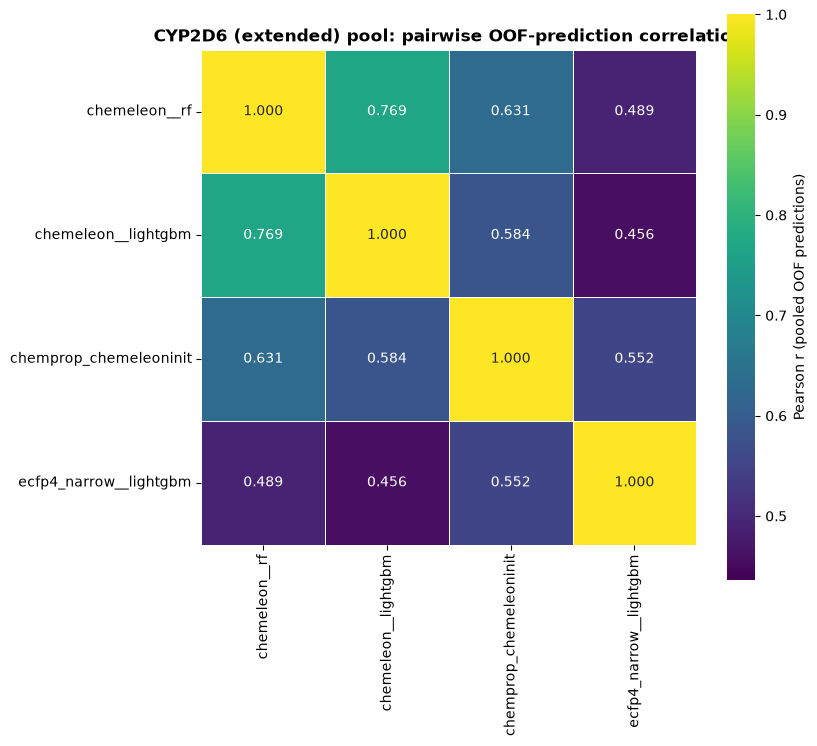

2026-09-03 11:35:10.301 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-03 11:35:10.302 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:35:10.302 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2D6_pIC50_direct_inhibition


2026-09-03 11:35:10.302 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 686 compound(s) with no ground truth for endpoint CYP2D6_pIC50_direct_inhibition


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/08_ensemble_selection/figures/correlation_heatmap_CYP2D6_extended.png

current CYP2D6 champion (chemeleon__rf+chemprop_chemeleoninit): mean ST-RAE across 25 folds = 0.8772


...

2026-09-03 11:36:56.506 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:36:56.506 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2D6_pIC50_direct_inhibition


2026-09-03 11:36:56.506 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 686 compound(s) with no ground truth for endpoint CYP2D6_pIC50_direct_inhibition


2026-09-03 11:36:57.107 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions



scored 7 new combos including ecfp4_narrow__lightgbm, vs. current champion
                                                                          combo  n_members  champion_ST-RAE  combo_ST-RAE  delta_mean          test      p_value  significant
                    chemeleon__rf+chemprop_chemeleoninit+ecfp4_narrow__lightgbm          3         0.877152      0.876962   -0.000190 paired t-test 8.930990e-01        False
chemeleon__rf+chemeleon__lightgbm+chemprop_chemeleoninit+ecfp4_narrow__lightgbm          4         0.877152      0.878818    0.001666 paired t-test 3.843915e-01        False
              chemeleon__lightgbm+chemprop_chemeleoninit+ecfp4_narrow__lightgbm          3         0.877152      0.885743    0.008592 paired t-test 4.569913e-04         True
                                  chemprop_chemeleoninit+ecfp4_narrow__lightgbm          2         0.877152      0.895022    0.017871 paired t-test 9.011794e-08         True
                       chemeleon__rf+chemeleon__lightg

In [7]:
CYP2D6_POOL_EXTENDED = {**CYP2D6_POOL, "ecfp4_narrow__lightgbm": ("06", "residual__ecfp4_narrow__lightgbm")}
members_ext = list(CYP2D6_POOL_EXTENDED)
print(f"=== CYP2D6 (extended pool): {members_ext} ===")
wide_ext = build_pool_wide(CYP2D6_POOL_EXTENDED, "CYP2D6_pIC50_direct_inhibition")

corr_ext = wide_ext[members_ext].corr(method="pearson")
print("pairwise Pearson r (pooled OOF predictions, all 25 folds):")
print(corr_ext.round(3).to_string())
plot_correlation_heatmap(wide_ext, members_ext, "CYP2D6 (extended)", FIG_OUT / "correlation_heatmap_CYP2D6_extended.png")

champion_combo = outcome_2d6["winning_combo"]
champion_st_rae = combo_df_2d6[combo_df_2d6["combo"] == champion_combo].sort_values(["repeat", "fold"])["ST-RAE"].to_numpy()
print(f"\ncurrent CYP2D6 champion ({champion_combo}): mean ST-RAE across 25 folds = {champion_st_rae.mean():.4f}")

new_combo_rows, new_comparison_rows = [], []
for r in range(2, len(members_ext) + 1):
    for combo in itertools.combinations(members_ext, r):
        if "ecfp4_narrow__lightgbm" not in combo:
            continue  # already scored in the scoped 3-candidate run above
        combo_df = score_combo("CYP2D6", "CYP2D6_pIC50_direct_inhibition", wide_ext, combo, tag_prefix="CYP2D6_extended")
        combo_df = combo_df.sort_values(["repeat", "fold"]).reset_index(drop=True)
        new_combo_rows.append(combo_df)
        test = paired_test(champion_st_rae, combo_df["ST-RAE"].to_numpy())
        new_comparison_rows.append({"isoform": "CYP2D6", "combo": "+".join(combo), "n_members": r, "vs": f"champion ({champion_combo})", **test})

new_combo_df_2d6 = pd.concat(new_combo_rows, ignore_index=True)
new_comparison_df_2d6 = pd.DataFrame(new_comparison_rows).sort_values("after_mean").reset_index(drop=True)
print(f"\nscored {len(new_comparison_df_2d6)} new combos including ecfp4_narrow__lightgbm, vs. current champion")
print(new_comparison_df_2d6[["combo", "n_members", "before_mean", "after_mean", "delta_mean", "test", "p_value", "significant"]]
      .rename(columns={"before_mean": "champion_ST-RAE", "after_mean": "combo_ST-RAE"}).to_string(index=False))

eligible_ext = new_comparison_df_2d6[new_comparison_df_2d6["significant"] & (new_comparison_df_2d6["delta_mean"] < 0)]
if len(eligible_ext) > 0:
    winner_ext = eligible_ext.loc[eligible_ext["after_mean"].idxmin()]
    print(f"\nRESULT: '{winner_ext['combo']}' beats the current champion significantly "
          f"(ST-RAE {champion_st_rae.mean():.4f} -> {winner_ext['after_mean']:.4f}, {winner_ext['test']} p={winner_ext['p_value']:.3g}) "
          f"-- CONFIRMED: keep ecfp4_narrow__lightgbm, CYP2D6's step-3 winner updates to '{winner_ext['combo']}'.")
    outcome_2d6 = {
        "isoform": "CYP2D6", "decision": "ensemble adopted", "winning_combo": winner_ext["combo"],
        "winning_mean_ST-RAE": winner_ext["after_mean"], "single_best_label": "chemeleon__rf (07 tuned)",
        "single_best_mean_ST-RAE": float(single_best_2d6["ST-RAE"].mean()), "p_value": winner_ext["p_value"], "test": winner_ext["test"],
    }
else:
    print(f"\nRESULT: no combo including ecfp4_narrow__lightgbm beats the current champion "
          f"({champion_combo}, ST-RAE {champion_st_rae.mean():.4f}) significantly -- "
          f"CONFIRMED: exclusion stands, no change to CYP2D6's step-3 outcome.")

step3_outcomes[:] = [o for o in step3_outcomes if o["isoform"] != "CYP2D6"] + [outcome_2d6]
all_combo_rows.append(new_combo_df_2d6)
all_comparison_rows.append(new_comparison_df_2d6)
combo_df_2d6 = pd.concat([combo_df_2d6, new_combo_df_2d6], ignore_index=True)

**What this shows:** none of the 7 combos including `ecfp4_narrow__lightgbm`
beat the current champion. The closest, adding it to the champion pair
(`chemeleon__rf + chemprop_chemeleoninit + ecfp4_narrow__lightgbm`), is
statistically indistinguishable from the champion itself (ST-RAE 0.8772 ->
0.8770, p=0.89) -- not an improvement, just noise. Every other combo
including it is either not significant or **significantly worse** (2 of the
7), consistent with the pairwise correlation above: `ecfp4_narrow__lightgbm`
correlates more weakly with the pool (r=0.46-0.55) not because it's usefully
complementary, but because it's simply the weakest individual predictor of
the four (its own 06 residual-excluded ST-RAE, 0.9463, is well behind all
three pool members) -- low correlation from being a worse model, not from
carrying independent signal that helps the average. **CONFIRMED: the
exclusion stands.** CYP2D6's step-3 outcome is unchanged: `chemeleon__rf +
chemprop_chemeleoninit` (ST-RAE 0.8968 -> 0.8772) remains the winner, and
`ecfp4_narrow__lightgbm` is not part of it.

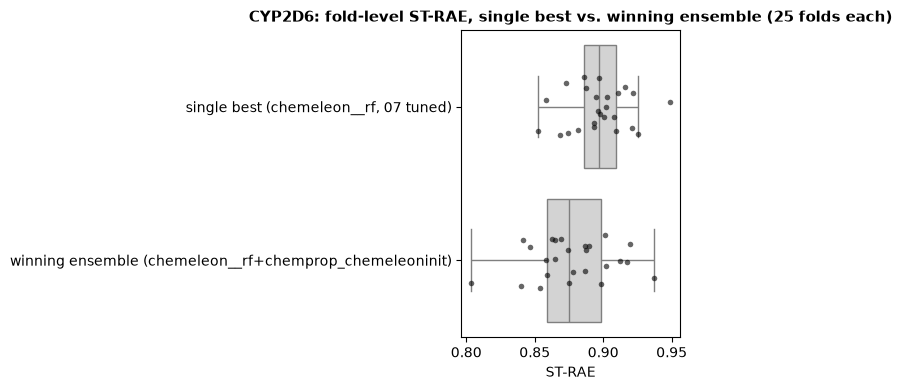

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/08_ensemble_selection/figures/before_after_CYP2D6.png


In [8]:
if outcome_2d6["decision"] == "ensemble adopted":
    winning_members = outcome_2d6["winning_combo"].split("+")
    winning_df = combo_df_2d6[combo_df_2d6["combo"] == outcome_2d6["winning_combo"]].sort_values(["repeat", "fold"])
    dist_df = pd.concat([
        pd.DataFrame({"ST-RAE": single_best_2d6["ST-RAE"].to_numpy(), "model": "single best (chemeleon__rf, 07 tuned)"}),
        pd.DataFrame({"ST-RAE": winning_df["ST-RAE"].to_numpy(), "model": f"winning ensemble ({outcome_2d6['winning_combo']})"}),
    ], ignore_index=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    order = dist_df["model"].unique().tolist()
    sns.boxplot(data=dist_df, x="ST-RAE", y="model", order=order, ax=ax, color="lightgray", fliersize=0, linewidth=1)
    sns.stripplot(data=dist_df, x="ST-RAE", y="model", order=order, ax=ax, color="black", size=4, alpha=0.6, jitter=0.2)
    ax.set_title("CYP2D6: fold-level ST-RAE, single best vs. winning ensemble (25 folds each)", fontsize=11, fontweight="bold")
    ax.set_ylabel("")
    plt.tight_layout()
    path = FIG_OUT / "before_after_CYP2D6.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {path}")
else:
    print("CYP2D6: single model stands -- no before/after distribution plot to make.")

**What this shows:** the winning ensemble's 25 fold-level ST-RAE values sit
visibly lower than the single best model's, with the two distributions barely
overlapping -- the same fold-level view 06/07 used for their own before/after
checks, now showing this step's chosen combo against the single best it
replaces for CYP2D6.

## CYP3A4

**Candidate pool** (05 CLD leaderboard, `leaderboard_CYP3A4.csv`, Section 3):
the two configs sharing CLD letter **"a"** -- `chemprop_chemeleoninit`,
`ecfp4_narrow__lightgbm` -- statistically indistinguishable on ST-RAE at
alpha=0.05. 2 candidates -> **1 non-trivial subset** (the pair). Current
single best: `chemprop_chemeleoninit` (ST-RAE 0.5461 vs. 0.5706).

In [9]:
CYP3A4_POOL = {
    "chemprop_chemeleoninit": ("05", "chemprop_chemeleoninit"),
    "ecfp4_narrow__lightgbm": ("05", "ecfp4_narrow__lightgbm"),
}

leaderboard_3a4 = pd.read_csv(OUT05 / "leaderboard_CYP3A4.csv")
print(leaderboard_3a4[leaderboard_3a4["config"].isin(CYP3A4_POOL)][["CLD", "config", "ST-RAE"]].to_string(index=False))
assert set(leaderboard_3a4.loc[leaderboard_3a4["CLD"] == "a", "config"]) == set(CYP3A4_POOL), "CYP3A4 pool does not match 05's CLD tier 'a'"

combo_df_3a4, comparison_df_3a4, outcome_3a4, single_best_3a4 = run_isoform_ensemble_selection(
    "CYP3A4", CYP3A4_POOL, single_best_label="chemprop_chemeleoninit", single_best_source="05", single_best_tag="chemprop_chemeleoninit",
)
all_combo_rows.append(combo_df_3a4)
all_comparison_rows.append(comparison_df_3a4)
step3_outcomes.append(outcome_3a4)

CLD                 config   ST-RAE
  a chemprop_chemeleoninit 0.546056
  a ecfp4_narrow__lightgbm 0.570599
=== CYP3A4: pool = ['chemprop_chemeleoninit', 'ecfp4_narrow__lightgbm'] ===
  loaded chemprop_chemeleoninit (05/chemprop_chemeleoninit): 24525 rows (25 folds)
  loaded ecfp4_narrow__lightgbm (05/ecfp4_narrow__lightgbm): 24525 rows (25 folds)
  pool wide table after inner-join on (repeat, fold, inchikey): 24525 rows (first member alone: 24525 rows)
pairwise Pearson r (pooled OOF predictions, all 25 folds):
                        chemprop_chemeleoninit  ecfp4_narrow__lightgbm
chemprop_chemeleoninit                   1.000                   0.814
ecfp4_narrow__lightgbm                   0.814                   1.000


2026-09-03 11:36:57.379 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-03 11:36:57.380 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:36:57.380 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-03 11:36:57.381 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 531 compound(s) with no ground truth for endpoint CYP3A4_pIC50_direct_inhibition


...

2026-09-03 11:37:12.719 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 22 columns.


2026-09-03 11:37:12.719 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP3A4_pIC50_direct_inhibition


2026-09-03 11:37:12.719 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 486 compound(s) with no ground truth for endpoint CYP3A4_pIC50_direct_inhibition


2026-09-03 11:37:13.352 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:169 - Completed scoring activity predictions



scored 1 non-trivial combos for CYP3A4
                                        combo  n_members  single_best_ST-RAE  combo_ST-RAE  delta_mean          test      p_value  significant
chemprop_chemeleoninit+ecfp4_narrow__lightgbm          2            0.546056      0.502901   -0.043155 paired t-test 2.027235e-07         True

DECISION: 'chemprop_chemeleoninit+ecfp4_narrow__lightgbm' wins for CYP3A4 -- ST-RAE 0.5461 -> 0.5029, paired t-test p=2.03e-07


**What this shows:** CYP3A4's only non-trivial subset -- the pair itself --
beats `chemprop_chemeleoninit` decisively (ST-RAE 0.5461 -> 0.5029, paired
t-test p=2.0e-07), despite the two members being fairly correlated (r=0.814).
With only one combo possible, there's no alternative to compare it against
beyond the single best it's already shown to beat.

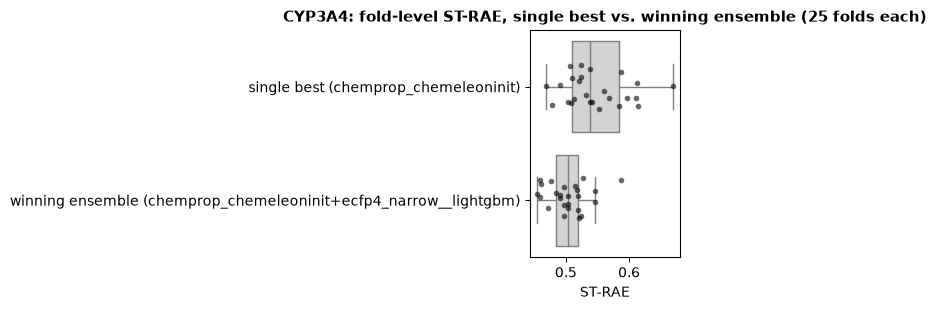

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/08_ensemble_selection/figures/before_after_CYP3A4.png


In [10]:
if outcome_3a4["decision"] == "ensemble adopted":
    winning_df = combo_df_3a4[combo_df_3a4["combo"] == outcome_3a4["winning_combo"]].sort_values(["repeat", "fold"])
    dist_df = pd.concat([
        pd.DataFrame({"ST-RAE": single_best_3a4["ST-RAE"].to_numpy(), "model": "single best (chemprop_chemeleoninit)"}),
        pd.DataFrame({"ST-RAE": winning_df["ST-RAE"].to_numpy(), "model": f"winning ensemble ({outcome_3a4['winning_combo']})"}),
    ], ignore_index=True)
    fig, ax = plt.subplots(figsize=(7, 3.2))
    order = dist_df["model"].unique().tolist()
    sns.boxplot(data=dist_df, x="ST-RAE", y="model", order=order, ax=ax, color="lightgray", fliersize=0, linewidth=1)
    sns.stripplot(data=dist_df, x="ST-RAE", y="model", order=order, ax=ax, color="black", size=4, alpha=0.6, jitter=0.2)
    ax.set_title("CYP3A4: fold-level ST-RAE, single best vs. winning ensemble (25 folds each)", fontsize=11, fontweight="bold")
    ax.set_ylabel("")
    plt.tight_layout()
    path = FIG_OUT / "before_after_CYP3A4.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {path}")
else:
    print("CYP3A4: single model stands -- no before/after distribution plot to make.")

**What this shows:** the winning pair's 25 fold-level ST-RAE values sit
consistently below `chemprop_chemeleoninit`'s alone, mirroring CYP2D6's
before/after view above and consistent with the large, highly significant
mean improvement found in Section CYP3A4.

## Final outcome summary -- for step 4 to consume directly

One row per isoform: the decision (ensemble adopted vs. single model stands),
the winning combo (if any), and the resulting mean ST-RAE -- this is what step
4 (placement/recalibration) should read to know which prediction source to use
per isoform going forward.

In [11]:
step3_summary = pd.DataFrame(step3_outcomes)[
    ["isoform", "decision", "winning_combo", "winning_mean_ST-RAE", "single_best_label", "single_best_mean_ST-RAE", "test", "p_value"]
]
print(step3_summary.to_string(index=False))

summary_path = OUT / "step3_summary.csv"
step3_summary.to_csv(summary_path, index=False)
print(f"\nwrote {summary_path}")

combo_summary_table = pd.concat(all_combo_rows, ignore_index=True)
combo_summary_path = OUT / "combo_summary_table.csv"
combo_summary_table.to_csv(combo_summary_path, index=False)
print(f"wrote {combo_summary_path}: {combo_summary_table.shape}")

pairwise_comparisons = pd.concat(all_comparison_rows, ignore_index=True)
pairwise_comparisons_path = OUT / "pairwise_comparisons.csv"
pairwise_comparisons.to_csv(pairwise_comparisons_path, index=False)
print(f"wrote {pairwise_comparisons_path}: {pairwise_comparisons.shape}")

isoform                                 decision                                                                winning_combo  winning_mean_ST-RAE        single_best_label  single_best_mean_ST-RAE          test      p_value
 CYP1A2                         ensemble adopted chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf+ecfp4_narrow__lightgbm             0.802210   chemprop_chemeleoninit                 0.868459 paired t-test 6.298245e-09
 CYP2C9 single model stands (no ensemble tested)                                                                         None             0.678691   chemprop_chemeleoninit                 0.678691          None          NaN
 CYP2D6                         ensemble adopted                                         chemeleon__rf+chemprop_chemeleoninit             0.877152 chemeleon__rf (07 tuned)                 0.896770 paired t-test 2.789724e-06
 CYP3A4                         ensemble adopted                                chemprop_chemeleoninit+e

**What this shows:** three of the four isoforms get an ensemble adopted --
CYP1A2 (the full 4-way average), CYP2D6 (`chemeleon__rf + chemprop_
chemeleoninit`), and CYP3A4 (its only pair) -- each beating its prior single
best significantly, with no correction applied across these tests since each
isoform's comparison is independent and uncorrected, matching 06/07's own
convention. CYP2C9 has no ensemble by design (a single, uniquely-best
candidate) and carries its 05 result forward unchanged. CYP2D6's `ecfp4_narrow__lightgbm` exclusion was separately re-tested against an extended 4-candidate pool (addendum above) and confirmed -- no combo including it beat the champion. `step3_summary.csv`
above is what step 4 (placement/recalibration) should read directly: for
CYP1A2/CYP2D6/CYP3A4, the winning combo's simple-average predictions (already
saved per-fold under `outputs/08_ensemble_selection/predictions/`) are this
project's current best CYP-isoform models; for CYP2C9, `chemprop_
chemeleoninit`'s existing 05 predictions remain the answer.